### ***Understanding Function Transformer***

In [73]:
np.random.seed(42)

X1 = np.random.exponential(scale=2.0, size=100)
X2 = np.random.exponential(scale=3.0, size=100)

log_odds = -3 + 1.5 * np.log1p(X1) + 1.2 * np.log1p(X2)

# Add Gaussian noise to log_odds before computing prob
noise = np.random.normal(loc=0, scale=1.5, size=100)  # tune scale to control difficulty
log_odds_noisy = log_odds + noise

prob = 1 / (1 + np.exp(-log_odds_noisy))
y = (prob > 0.5).astype(int)

print("Class distribution:", np.bincount(y))

Class distribution: [57 43]


In [74]:
import pandas as pd
df = pd.DataFrame({'feature1':X1 , 'feature2':X2 , 'class':y})
print(df.head())

   feature1  feature2  class
0  0.938536  0.095801      0
1  6.020243  3.035189      1
2  2.633491  1.132190      1
3  1.825885  2.131312      0
4  0.339250  7.143797      1


In [75]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   feature1  100 non-null    float64
 1   feature2  100 non-null    float64
 2   class     100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


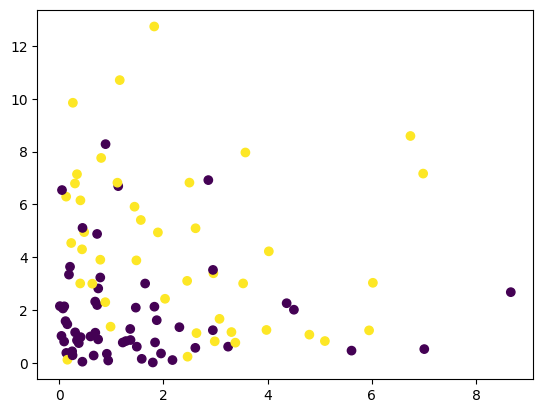

In [76]:
# Plot the data
plt.scatter(df['feature1'] , df['feature2'] , c = df['class'])

**I have generated synthetic data to study Function Transformer and use of Mathematical Transforms**

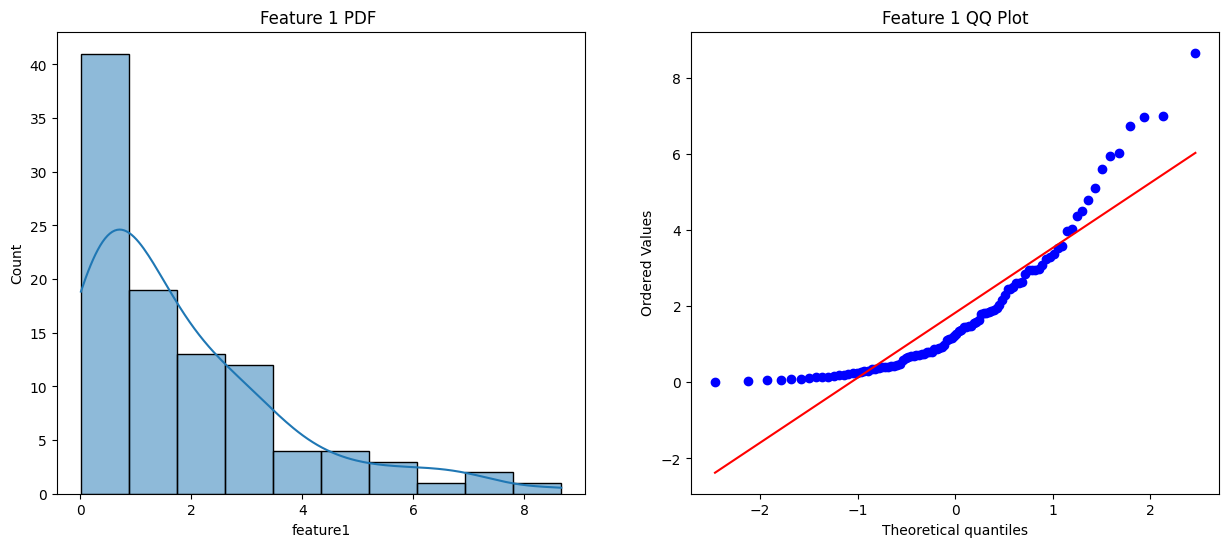

In [77]:
# Let us see how our features are distributed
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,6))
plt.subplot(121)
sns.histplot(x = df['feature1'] , kde=True)
plt.title('Feature 1 PDF ')
plt.subplot(122)
stats.probplot(df['feature1'] ,dist='norm', plot=plt )
plt.title('Feature 1 QQ Plot')
plt.show()

- Feature 1 is not normally distributed Also highly Right skewed
- We can use log transform to make it better

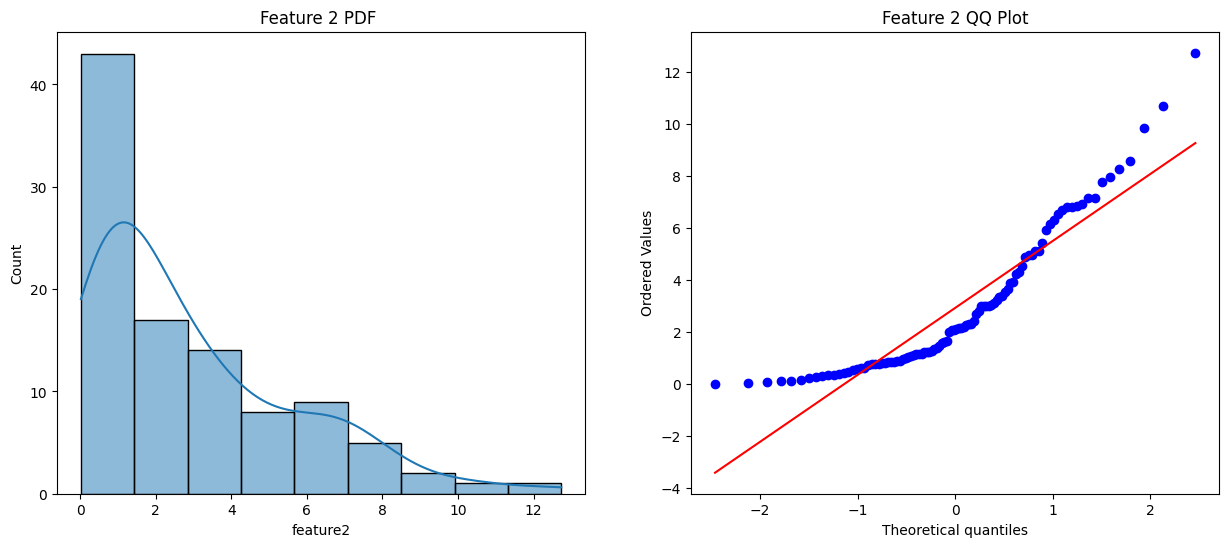

In [78]:
plt.figure(figsize=(15,6))
plt.subplot(121)
sns.histplot(x = df['feature2'] , kde=True)
plt.title('Feature 2 PDF ')
plt.subplot(122)
stats.probplot(df['feature2'] ,dist='norm', plot=plt )
plt.title('Feature 2 QQ Plot')
plt.show()

- This Feature is not Normally distributed 

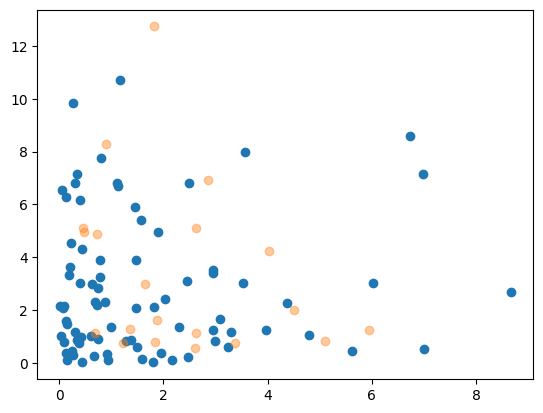

In [79]:
# Plot the data
plt.scatter(X_train['feature1'] , X_train['feature2'])
plt.scatter(X_test['feature1'] , X_test['feature2'], alpha=.4)

### **Model Evaluation On Original Data**

In [80]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

In [81]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

print(X.shape)
print(y.shape)

(100, 2)
(100,)


In [82]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2 , random_state=0)
X_train.reset_index(drop=True,inplace=True)
X_test.reset_index(drop=True,inplace=True)
y_train.reset_index(drop=True,inplace=True)
y_test.reset_index(drop=True,inplace=True)

print(X_train.shape)
print(y_train.shape)

(80, 2)
(80,)


In [83]:
X_train.head()

,feature1,feature2
0,4.800846,1.073791
1,3.529116,3.011513
2,1.825885,2.131312
3,0.443079,0.050181
4,2.172512,0.112753


In [84]:
y_train.head()

0    1
1    1
2    0
3    0
4    0
Name: class, dtype: int64

In [85]:
lr = LogisticRegression(max_iter=1000)
model = lr.fit(X_train , y_train)

y_pred = model.predict(X_test)
print(f'Accuracy Score -> {accuracy_score(y_test , y_pred)}')

Accuracy Score -> 0.55


### ***Cross Validation Before Transform***

In [100]:
lr = LogisticRegression()
np.mean(cross_val_score(lr , X , y , scoring='accuracy' , cv =10))

np.float64(0.7100000000000001)

### ***Log Transform The Features***

In [86]:
tnf = FunctionTransformer(func=np.log1p)

transformer = ColumnTransformer(transformers=[
    ('log' , tnf , ['feature1','feature2'])
] , remainder='passthrough')

transformer.set_output(transform = 'pandas')   # This directly transforms our tranformations into df again

X_train_tnf = transformer.fit_transform(X_train)
X_test_tnf =  transformer.transform(X_test)

In [87]:
X_train_tnf

,log__feature1,log__feature2
0,1.758004,0.729379
1,1.510527,1.389169
2,1.038822,1.141452
3,0.366779,0.048962
4,1.154524,0.106838
...,...,...
75,0.908000,1.585841
76,1.444791,0.481992
77,0.506580,0.249893
78,0.903498,1.129968


**We have transformed our Features**

Text(0.5, 1.0, 'Transformed Feature1')

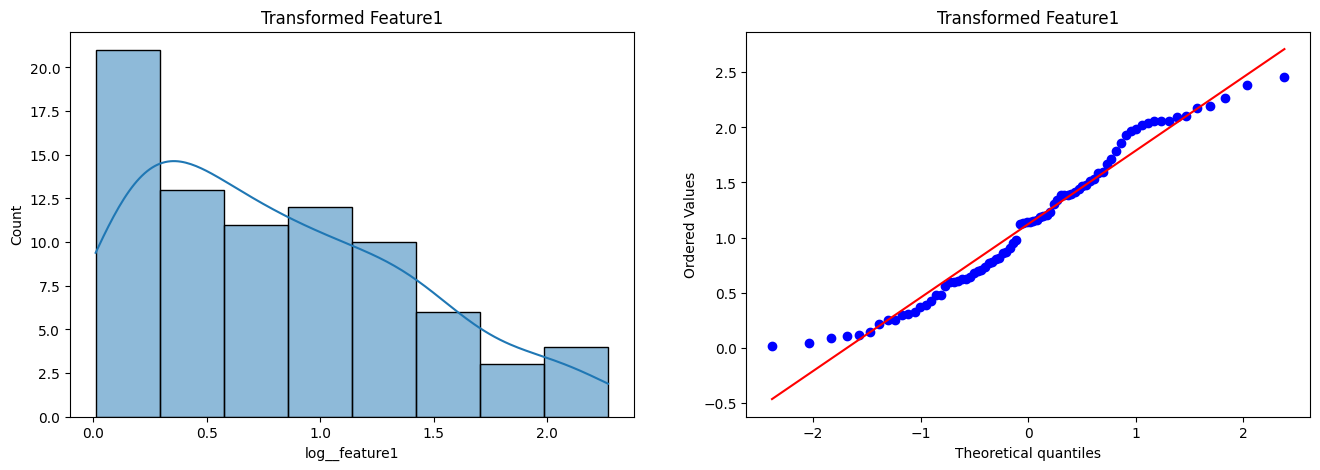

In [88]:
# Let us Plot them again
plt.figure(figsize=(16,5))
plt.subplot(121)
sns.histplot(X_train_tnf['log__feature1'] , kde=True)
plt.title('Transformed Feature1')
plt.subplot(122)
stats.probplot(X_train_tnf['log__feature2'] , dist='norm' , plot=plt)
plt.title('Transformed Feature1')

- We clearly see that After Transforming the Feature We got a better QQ Plot than before

Text(0.5, 1.0, 'Transformed Feature2')

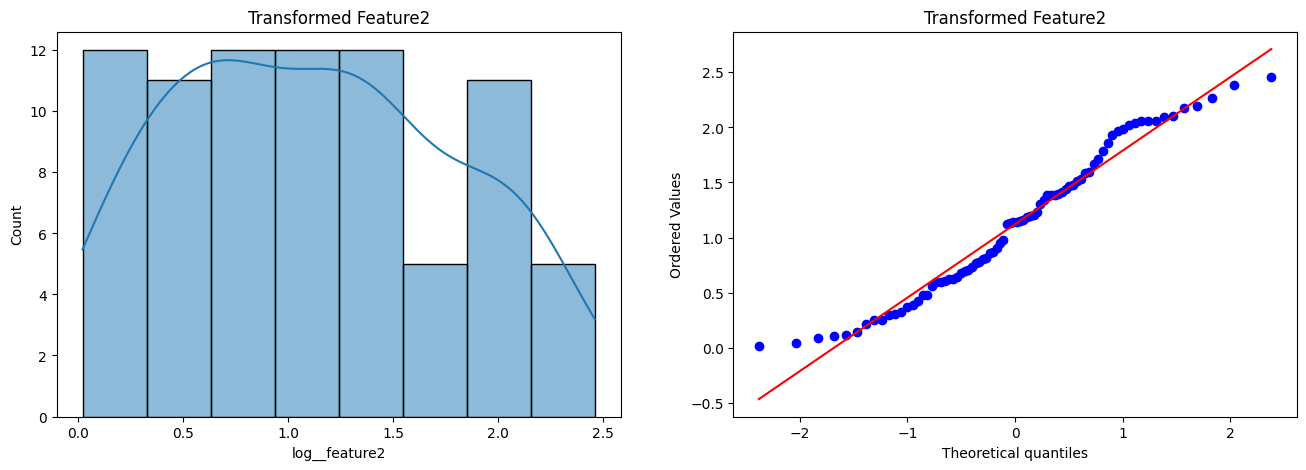

In [89]:
# Let us Plot them again
plt.figure(figsize=(16,5))
plt.subplot(121)
sns.histplot(X_train_tnf['log__feature2'] , kde=True)
plt.title('Transformed Feature2')
plt.subplot(122)
stats.probplot(X_train_tnf['log__feature2'] , dist='norm' , plot=plt)
plt.title('Transformed Feature2')

- We clearly see that After Transforming the Feature We got a better QQ Plot than before

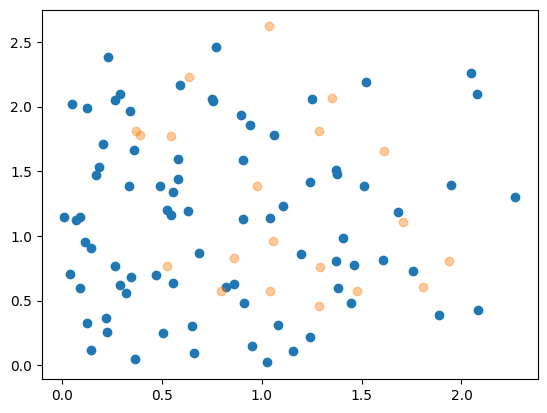

In [90]:
# Plot the data
plt.scatter(X_train_tnf['log__feature1'] , X_train_tnf['log__feature2'])
plt.scatter(X_test_tnf['log__feature1'] , X_test_tnf['log__feature2'], alpha=.4)

### **Model Evaluation After Transformation**

In [99]:
lr = LogisticRegression(max_iter=1000)
model= lr.fit(X_train_tnf , y_train)

y_pred_tnf = model.predict(X_test_tnf)

print(f"Acc Score Post Tnf -> {accuracy_score(y_test , y_pred_tnf)}")

Acc Score Post Tnf -> 0.55


### ***Let us use cross validation***

In [98]:
X_tnf = tnf.fit_transform(X)
lr = LogisticRegression()
np.mean(cross_val_score(lr , X_tnf , y , scoring='accuracy' , cv =10))

np.float64(0.72)

### ***Custom Transformation and Evaluation***

Original -> 0.7100000000000001
x -> x**2 -> 0.69
x -> x**0.5 -> 0.7100000000000001
x -> logx -> 0.72
x -> sinx -> 0.6799999999999999
x -> cosx -> 0.58


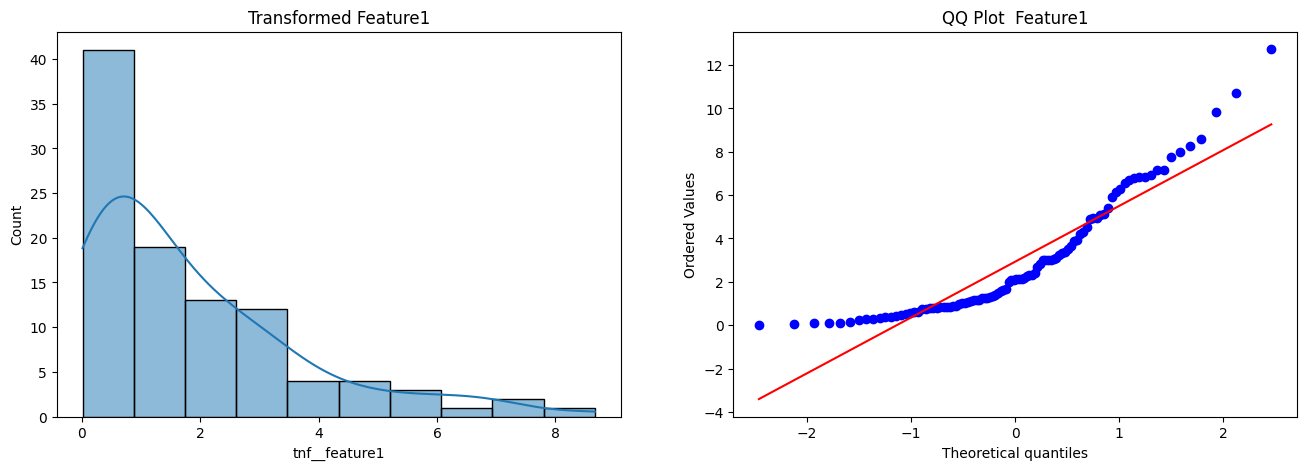

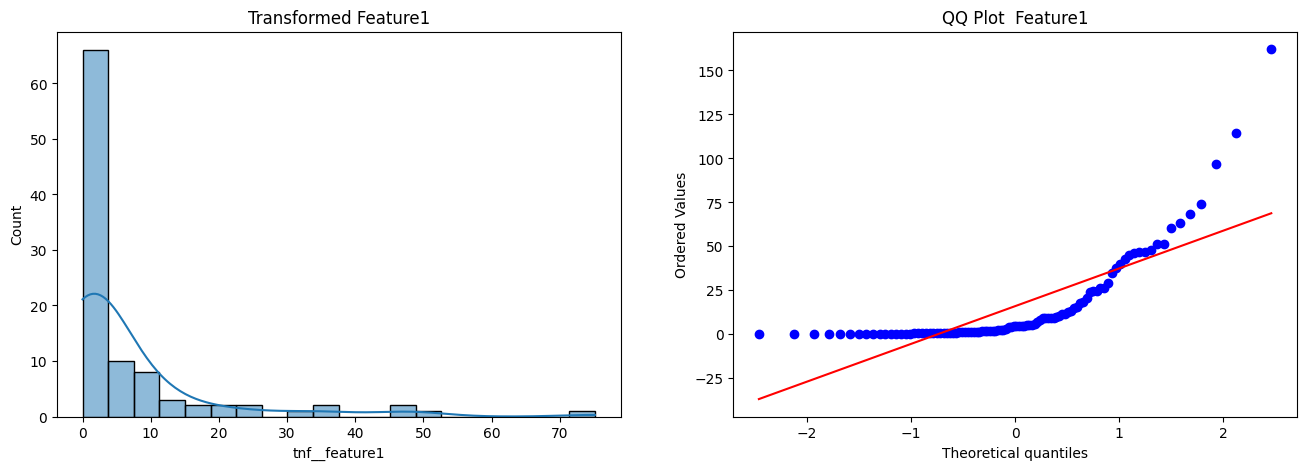

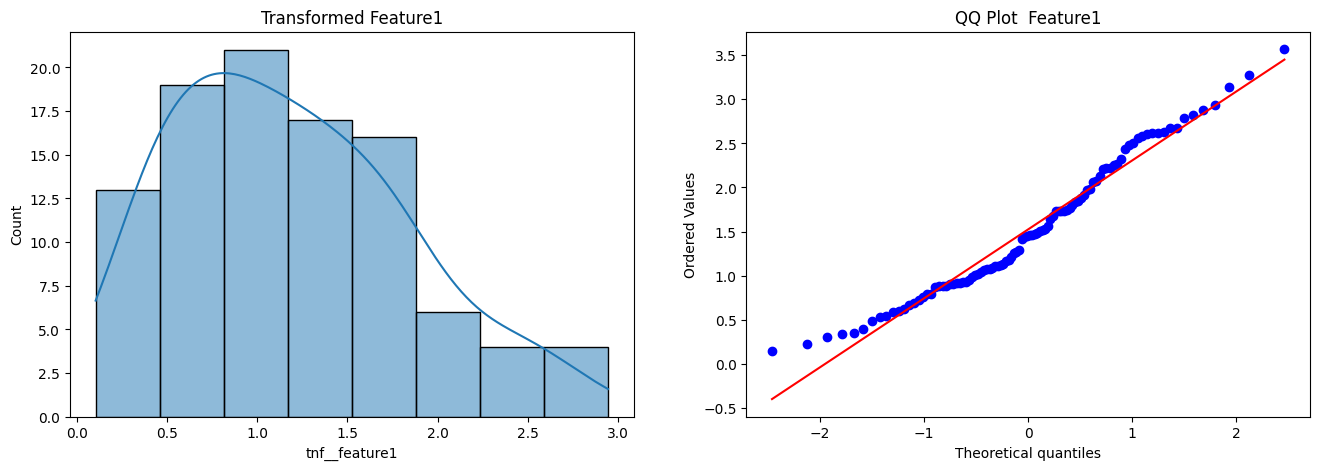

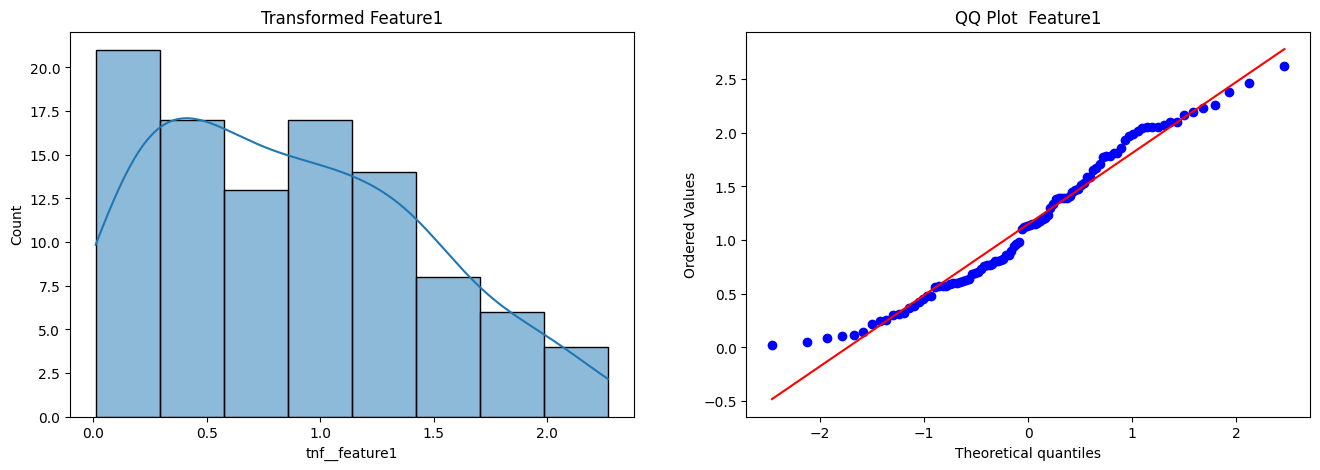

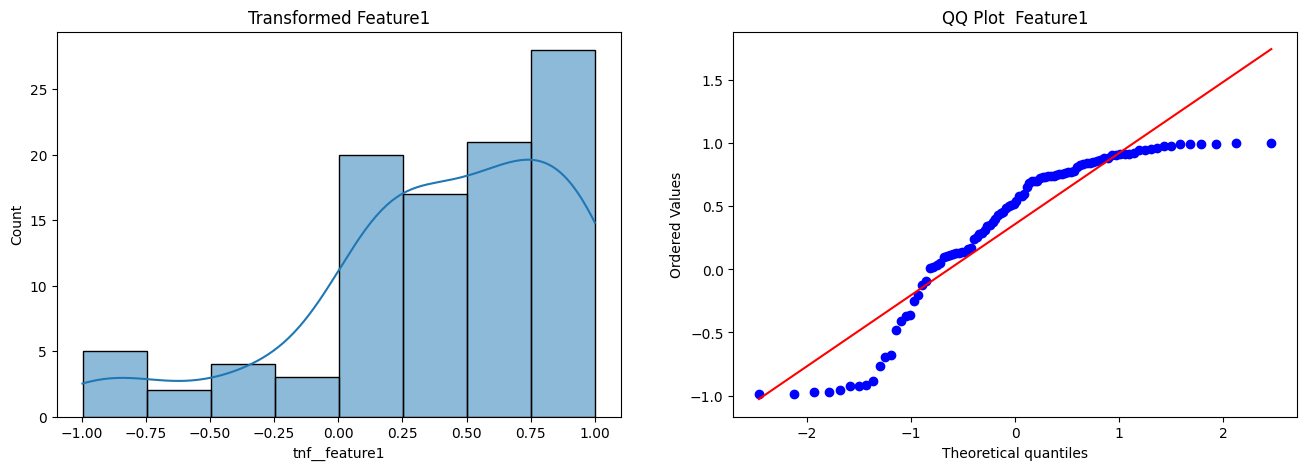

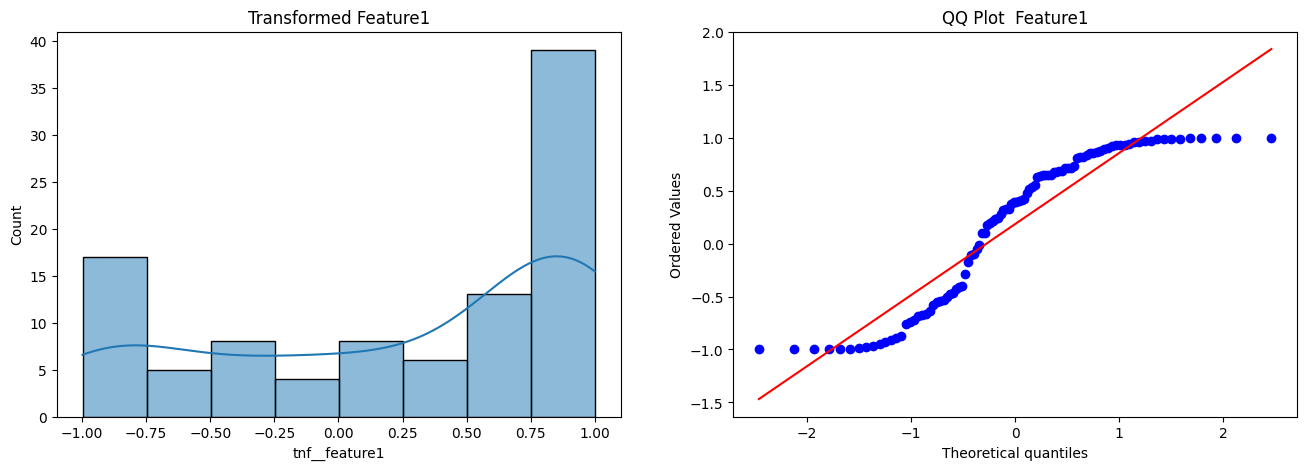

In [119]:
def custom_transform(transformation):
    X = df.iloc[:,:-1]
    y = df.iloc[:,-1]

    tnf = FunctionTransformer(transformation)

    transformer = ColumnTransformer(transformers=[
        ('tnf' , tnf , ['feature1','feature2'])
    ] , remainder='passthrough')

    transformer.set_output(transform = 'pandas')   # This directly transforms our tranformations into df again

    X_tnf = transformer.fit_transform(X)
    lr = LogisticRegression()
    # Let us Plot them again
    plt.figure(figsize=(16,5))
    plt.subplot(121)
    sns.histplot(X_tnf['tnf__feature1'] , kde=True)
    plt.title('Transformed Feature1')
    plt.subplot(122)
    stats.probplot(X_tnf['tnf__feature2'] , dist='norm' , plot=plt)
    plt.title(f'QQ Plot  Feature1')


    return np.mean(cross_val_score(lr , X_tnf , y , scoring='accuracy' , cv =10))


print(f"Original -> {custom_transform(lambda x:x)}")
print(f"x -> x**2 -> {custom_transform(lambda x:x**2)}")
print(f"x -> x**0.5 -> {custom_transform(lambda x:x**0.5)}")
print(f"x -> logx -> {custom_transform(np.log1p)}")
print(f"x -> sinx -> {custom_transform(np.sin)}")
print(f"x -> cosx -> {custom_transform(np.cos)}")


    
    